In [1]:
import time
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"Đang sử dụng GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("Không tìm thấy GPU, sử dụng CPU")

Không tìm thấy GPU, sử dụng CPU


In [3]:
# ----- Cấu hình -----
latent_dim = 100
batch_size = 256 if torch.cuda.is_available() else 64
lr = 0.0004
epochs = 300

In [4]:
# ----- Dataset -----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
train_loader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True,
    pin_memory=True if device.type == 'cuda' else False
)

In [5]:
# ----- Mạng Generator -----
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 28*28),
            nn.Tanh()  # output lung range [-1,1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(z.size(0), 1, 28, 28)
        return img

# ----- Mạng Discriminator -----
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid()  # output xác suất
        )

    def forward(self, img):
        return self.model(img)

In [6]:
# ----- Khởi tạo mô hình và tối ưu hóa -----
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

In [7]:
def model_params_size_bytes(model):
    params = sum(p.numel() * p.element_size() for p in model.parameters())
    buffers = sum(b.numel() * b.element_size() for b in model.buffers())
    return params + buffers

def n_paramters_approx(n_MB: float):
    n_Bytes = int(n_MB * (1024**2))
    n_parameters = n_Bytes // 4 #Cho rằng các tham số có kiểu dữ liệu float32
    
    return int(n_parameters)

def bytes_to_mb(b):
    return b / (1024**2)

generator_parameters_size = bytes_to_mb(model_params_size_bytes(generator))
discriminator_parameters_size = bytes_to_mb(model_params_size_bytes(discriminator))
total_size = generator_parameters_size + discriminator_parameters_size
print(f"Numbers of parameters: {n_paramters_approx(total_size):,}")

print(f"Model size (MB):\n\tGenerator: {generator_parameters_size:.2f} (MB)\n\tDiscriminator: {discriminator_parameters_size:.2f} (MB)\n\tTotal: {total_size:.2f} (MB)")

Numbers of parameters: 481,425
Model size (MB):
	Generator: 0.94 (MB)
	Discriminator: 0.89 (MB)
	Total: 1.84 (MB)


In [8]:
# Storage for metrics
history = {'epoch': 0, 'loss_D': [], 'loss_G': [], 'epoch_time_sec': []}

[Epoch 1/300] Loss_D: 0.1040, Loss_G: 5.1411, Time: 13.81s


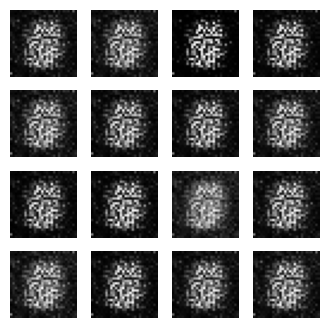

[Epoch 2/300] Loss_D: 0.3177, Loss_G: 4.5069, Time: 25.92s
[Epoch 3/300] Loss_D: 0.4977, Loss_G: 2.6824, Time: 43.31s
[Epoch 4/300] Loss_D: 0.3209, Loss_G: 2.6561, Time: 60.17s
[Epoch 5/300] Loss_D: 0.3168, Loss_G: 3.1908, Time: 85.39s
[Epoch 6/300] Loss_D: 0.3117, Loss_G: 3.1723, Time: 115.05s
[Epoch 7/300] Loss_D: 0.1989, Loss_G: 3.7278, Time: 145.94s
[Epoch 8/300] Loss_D: 0.2676, Loss_G: 4.0138, Time: 168.95s
[Epoch 9/300] Loss_D: 0.2486, Loss_G: 2.8807, Time: 183.67s
[Epoch 10/300] Loss_D: 0.2880, Loss_G: 3.1920, Time: 208.04s
[Epoch 11/300] Loss_D: 0.2261, Loss_G: 3.0715, Time: 230.96s
[Epoch 12/300] Loss_D: 0.2216, Loss_G: 3.6120, Time: 255.40s
[Epoch 13/300] Loss_D: 0.2326, Loss_G: 3.5982, Time: 277.83s
[Epoch 14/300] Loss_D: 0.2373, Loss_G: 3.3145, Time: 299.85s
[Epoch 15/300] Loss_D: 0.2430, Loss_G: 3.1375, Time: 320.34s
[Epoch 16/300] Loss_D: 0.2412, Loss_G: 3.3905, Time: 341.95s
[Epoch 17/300] Loss_D: 0.2629, Loss_G: 3.2579, Time: 360.89s
[Epoch 18/300] Loss_D: 0.2562, Loss_

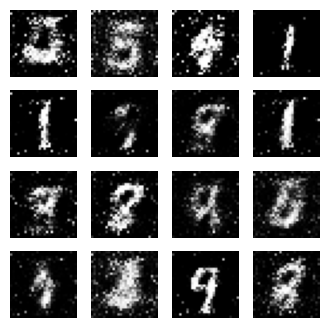

[Epoch 21/300] Loss_D: 0.2844, Loss_G: 3.0957, Time: 428.41s
[Epoch 22/300] Loss_D: 0.2863, Loss_G: 2.7781, Time: 450.97s
[Epoch 23/300] Loss_D: 0.3023, Loss_G: 2.5807, Time: 480.61s
[Epoch 24/300] Loss_D: 0.3002, Loss_G: 2.6066, Time: 507.45s
[Epoch 25/300] Loss_D: 0.3058, Loss_G: 2.5421, Time: 534.02s
[Epoch 26/300] Loss_D: 0.2808, Loss_G: 2.9884, Time: 560.93s
[Epoch 27/300] Loss_D: 0.3021, Loss_G: 2.6765, Time: 587.92s
[Epoch 28/300] Loss_D: 0.3237, Loss_G: 2.4348, Time: 614.33s
[Epoch 29/300] Loss_D: 0.3395, Loss_G: 2.3336, Time: 640.92s
[Epoch 30/300] Loss_D: 0.3613, Loss_G: 2.2527, Time: 667.49s
[Epoch 31/300] Loss_D: 0.3640, Loss_G: 2.2351, Time: 694.12s
[Epoch 32/300] Loss_D: 0.3466, Loss_G: 2.2950, Time: 720.36s
[Epoch 33/300] Loss_D: 0.3411, Loss_G: 2.4566, Time: 746.30s
[Epoch 34/300] Loss_D: 0.3539, Loss_G: 2.2378, Time: 769.51s
[Epoch 35/300] Loss_D: 0.3655, Loss_G: 2.1571, Time: 786.37s
[Epoch 36/300] Loss_D: 0.3724, Loss_G: 2.1224, Time: 799.81s
[Epoch 37/300] Loss_D: 0

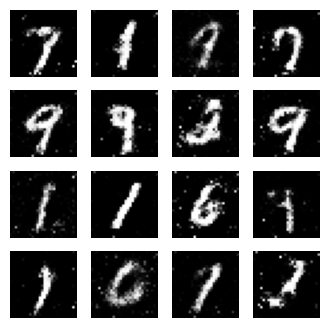

[Epoch 41/300] Loss_D: 0.3989, Loss_G: 2.0273, Time: 864.67s
[Epoch 42/300] Loss_D: 0.4069, Loss_G: 1.9597, Time: 885.96s
[Epoch 43/300] Loss_D: 0.4123, Loss_G: 1.9163, Time: 912.43s
[Epoch 44/300] Loss_D: 0.4131, Loss_G: 1.9100, Time: 929.80s
[Epoch 45/300] Loss_D: 0.4136, Loss_G: 1.9429, Time: 941.93s
[Epoch 46/300] Loss_D: 0.4140, Loss_G: 1.8957, Time: 954.59s
[Epoch 47/300] Loss_D: 0.4111, Loss_G: 1.9363, Time: 966.66s
[Epoch 48/300] Loss_D: 0.4137, Loss_G: 1.9930, Time: 979.95s
[Epoch 49/300] Loss_D: 0.4268, Loss_G: 1.8598, Time: 992.75s
[Epoch 50/300] Loss_D: 0.4296, Loss_G: 1.8208, Time: 1005.59s
[Epoch 51/300] Loss_D: 0.4351, Loss_G: 1.8235, Time: 1017.58s
[Epoch 52/300] Loss_D: 0.4362, Loss_G: 1.7695, Time: 1030.05s
[Epoch 53/300] Loss_D: 0.4427, Loss_G: 1.7887, Time: 1041.98s
[Epoch 54/300] Loss_D: 0.4452, Loss_G: 1.7277, Time: 1054.63s
[Epoch 55/300] Loss_D: 0.4421, Loss_G: 1.7534, Time: 1066.84s
[Epoch 56/300] Loss_D: 0.4473, Loss_G: 1.7540, Time: 1079.30s
[Epoch 57/300] Lo

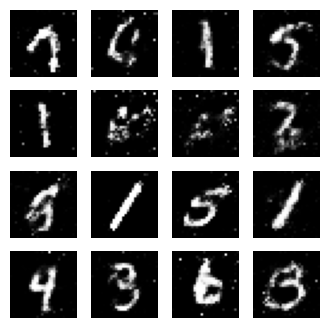

[Epoch 61/300] Loss_D: 0.4639, Loss_G: 1.6974, Time: 1141.11s
[Epoch 62/300] Loss_D: 0.4615, Loss_G: 1.6512, Time: 1153.44s
[Epoch 63/300] Loss_D: 0.4577, Loss_G: 1.6718, Time: 1165.50s
[Epoch 64/300] Loss_D: 0.4586, Loss_G: 1.6869, Time: 1177.73s
[Epoch 65/300] Loss_D: 0.4545, Loss_G: 1.6843, Time: 1190.20s
[Epoch 66/300] Loss_D: 0.4553, Loss_G: 1.7072, Time: 1202.32s
[Epoch 67/300] Loss_D: 0.4600, Loss_G: 1.6853, Time: 1214.77s
[Epoch 68/300] Loss_D: 0.4614, Loss_G: 1.6710, Time: 1227.41s
[Epoch 69/300] Loss_D: 0.4621, Loss_G: 1.6552, Time: 1239.52s
[Epoch 70/300] Loss_D: 0.4638, Loss_G: 1.6563, Time: 1252.68s
[Epoch 71/300] Loss_D: 0.4719, Loss_G: 1.6304, Time: 1265.83s
[Epoch 72/300] Loss_D: 0.4663, Loss_G: 1.6123, Time: 1278.56s
[Epoch 73/300] Loss_D: 0.4791, Loss_G: 1.6200, Time: 1291.15s
[Epoch 74/300] Loss_D: 0.4757, Loss_G: 1.5886, Time: 1311.36s
[Epoch 75/300] Loss_D: 0.4807, Loss_G: 1.5576, Time: 1336.77s
[Epoch 76/300] Loss_D: 0.4839, Loss_G: 1.5439, Time: 1361.87s
[Epoch 7

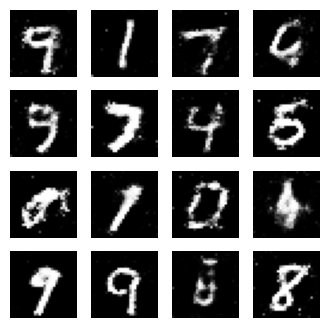

[Epoch 81/300] Loss_D: 0.4862, Loss_G: 1.5373, Time: 1481.88s
[Epoch 82/300] Loss_D: 0.4852, Loss_G: 1.5390, Time: 1507.38s
[Epoch 83/300] Loss_D: 0.4889, Loss_G: 1.4984, Time: 1532.83s
[Epoch 84/300] Loss_D: 0.4937, Loss_G: 1.5065, Time: 1558.87s
[Epoch 85/300] Loss_D: 0.4910, Loss_G: 1.5433, Time: 1585.12s
[Epoch 86/300] Loss_D: 0.4928, Loss_G: 1.4925, Time: 1610.75s
[Epoch 87/300] Loss_D: 0.4911, Loss_G: 1.5265, Time: 1636.76s
[Epoch 88/300] Loss_D: 0.4878, Loss_G: 1.5826, Time: 1660.55s
[Epoch 89/300] Loss_D: 0.4966, Loss_G: 1.5047, Time: 1679.90s
[Epoch 90/300] Loss_D: 0.4928, Loss_G: 1.5117, Time: 1705.46s
[Epoch 91/300] Loss_D: 0.4998, Loss_G: 1.4568, Time: 1730.81s
[Epoch 92/300] Loss_D: 0.4974, Loss_G: 1.5100, Time: 1756.59s
[Epoch 93/300] Loss_D: 0.4946, Loss_G: 1.5065, Time: 1782.17s
[Epoch 94/300] Loss_D: 0.5004, Loss_G: 1.4842, Time: 1794.57s
[Epoch 95/300] Loss_D: 0.5003, Loss_G: 1.4949, Time: 1809.19s
[Epoch 96/300] Loss_D: 0.5068, Loss_G: 1.4551, Time: 1827.41s
[Epoch 9

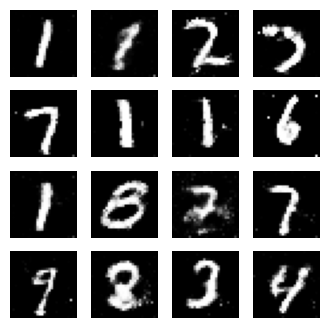

[Epoch 101/300] Loss_D: 0.5076, Loss_G: 1.4321, Time: 1932.36s
[Epoch 102/300] Loss_D: 0.5071, Loss_G: 1.4862, Time: 1955.59s
[Epoch 103/300] Loss_D: 0.5116, Loss_G: 1.4290, Time: 1982.07s
[Epoch 104/300] Loss_D: 0.5100, Loss_G: 1.4071, Time: 2008.14s
[Epoch 105/300] Loss_D: 0.5117, Loss_G: 1.4169, Time: 2033.95s
[Epoch 106/300] Loss_D: 0.5130, Loss_G: 1.4360, Time: 2060.36s
[Epoch 107/300] Loss_D: 0.5185, Loss_G: 1.4228, Time: 2085.46s
[Epoch 108/300] Loss_D: 0.5189, Loss_G: 1.3749, Time: 2102.29s
[Epoch 109/300] Loss_D: 0.5165, Loss_G: 1.4009, Time: 2119.68s
[Epoch 110/300] Loss_D: 0.5144, Loss_G: 1.3941, Time: 2136.84s
[Epoch 111/300] Loss_D: 0.5188, Loss_G: 1.4138, Time: 2154.22s
[Epoch 112/300] Loss_D: 0.5176, Loss_G: 1.4047, Time: 2172.76s
[Epoch 113/300] Loss_D: 0.5165, Loss_G: 1.4018, Time: 2195.55s
[Epoch 114/300] Loss_D: 0.5195, Loss_G: 1.3755, Time: 2213.61s
[Epoch 115/300] Loss_D: 0.5208, Loss_G: 1.3866, Time: 2232.55s
[Epoch 116/300] Loss_D: 0.5227, Loss_G: 1.3922, Time: 2

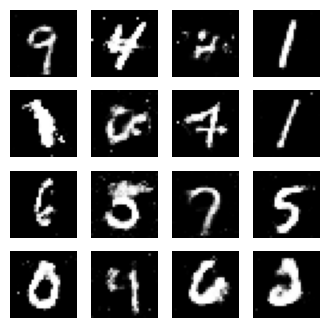

[Epoch 121/300] Loss_D: 0.5248, Loss_G: 1.3523, Time: 2345.19s
[Epoch 122/300] Loss_D: 0.5222, Loss_G: 1.3741, Time: 2375.93s
[Epoch 123/300] Loss_D: 0.5206, Loss_G: 1.3829, Time: 2405.67s
[Epoch 124/300] Loss_D: 0.5256, Loss_G: 1.3662, Time: 2434.47s
[Epoch 125/300] Loss_D: 0.5268, Loss_G: 1.3702, Time: 2464.63s
[Epoch 126/300] Loss_D: 0.5211, Loss_G: 1.3635, Time: 2499.54s
[Epoch 127/300] Loss_D: 0.5235, Loss_G: 1.3663, Time: 2531.57s
[Epoch 128/300] Loss_D: 0.5234, Loss_G: 1.3620, Time: 2562.41s
[Epoch 129/300] Loss_D: 0.5212, Loss_G: 1.3772, Time: 2592.63s
[Epoch 130/300] Loss_D: 0.5250, Loss_G: 1.3662, Time: 2624.73s
[Epoch 131/300] Loss_D: 0.5203, Loss_G: 1.3606, Time: 2659.33s
[Epoch 132/300] Loss_D: 0.5208, Loss_G: 1.3739, Time: 2696.22s
[Epoch 133/300] Loss_D: 0.5206, Loss_G: 1.3745, Time: 2724.20s
[Epoch 134/300] Loss_D: 0.5248, Loss_G: 1.3415, Time: 2744.62s
[Epoch 135/300] Loss_D: 0.5241, Loss_G: 1.3700, Time: 2764.44s
[Epoch 136/300] Loss_D: 0.5231, Loss_G: 1.3561, Time: 2

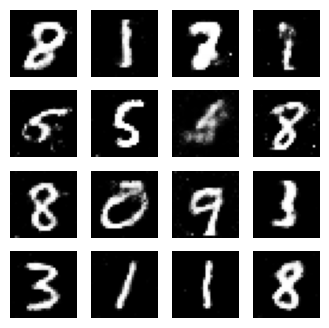

[Epoch 141/300] Loss_D: 0.5289, Loss_G: 1.3431, Time: 2853.10s
[Epoch 142/300] Loss_D: 0.5231, Loss_G: 1.3718, Time: 2867.20s
[Epoch 143/300] Loss_D: 0.5235, Loss_G: 1.3547, Time: 2881.40s
[Epoch 144/300] Loss_D: 0.5263, Loss_G: 1.3516, Time: 2894.79s
[Epoch 145/300] Loss_D: 0.5239, Loss_G: 1.3360, Time: 2910.06s
[Epoch 146/300] Loss_D: 0.5266, Loss_G: 1.3359, Time: 2927.06s
[Epoch 147/300] Loss_D: 0.5231, Loss_G: 1.3798, Time: 2941.76s
[Epoch 148/300] Loss_D: 0.5247, Loss_G: 1.3549, Time: 2955.35s
[Epoch 149/300] Loss_D: 0.5271, Loss_G: 1.3351, Time: 2970.35s
[Epoch 150/300] Loss_D: 0.5220, Loss_G: 1.3504, Time: 2984.19s
[Epoch 151/300] Loss_D: 0.5278, Loss_G: 1.3260, Time: 3000.01s
[Epoch 152/300] Loss_D: 0.5261, Loss_G: 1.3363, Time: 3016.08s
[Epoch 153/300] Loss_D: 0.5247, Loss_G: 1.3410, Time: 3042.83s
[Epoch 154/300] Loss_D: 0.5281, Loss_G: 1.3325, Time: 3069.81s
[Epoch 155/300] Loss_D: 0.5259, Loss_G: 1.3371, Time: 3096.40s
[Epoch 156/300] Loss_D: 0.5234, Loss_G: 1.3661, Time: 3

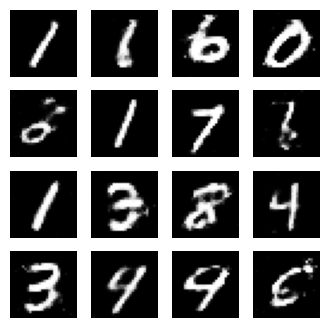

[Epoch 161/300] Loss_D: 0.5261, Loss_G: 1.3293, Time: 3220.16s
[Epoch 162/300] Loss_D: 0.5265, Loss_G: 1.3339, Time: 3235.94s
[Epoch 163/300] Loss_D: 0.5247, Loss_G: 1.3489, Time: 3251.34s
[Epoch 164/300] Loss_D: 0.5246, Loss_G: 1.3327, Time: 3265.25s
[Epoch 165/300] Loss_D: 0.5241, Loss_G: 1.3342, Time: 3278.46s
[Epoch 166/300] Loss_D: 0.5204, Loss_G: 1.3896, Time: 3291.76s
[Epoch 167/300] Loss_D: 0.5233, Loss_G: 1.3303, Time: 3305.23s
[Epoch 168/300] Loss_D: 0.5233, Loss_G: 1.3554, Time: 3318.26s
[Epoch 169/300] Loss_D: 0.5193, Loss_G: 1.3531, Time: 3331.40s
[Epoch 170/300] Loss_D: 0.5235, Loss_G: 1.3396, Time: 3343.87s
[Epoch 171/300] Loss_D: 0.5227, Loss_G: 1.3397, Time: 3356.67s
[Epoch 172/300] Loss_D: 0.5237, Loss_G: 1.3473, Time: 3369.90s
[Epoch 173/300] Loss_D: 0.5232, Loss_G: 1.3457, Time: 3382.34s
[Epoch 174/300] Loss_D: 0.5233, Loss_G: 1.3485, Time: 3395.12s
[Epoch 175/300] Loss_D: 0.5246, Loss_G: 1.3548, Time: 3407.41s
[Epoch 176/300] Loss_D: 0.5231, Loss_G: 1.3458, Time: 3

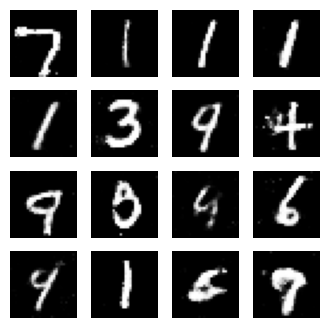

[Epoch 181/300] Loss_D: 0.5218, Loss_G: 1.3527, Time: 3492.71s
[Epoch 182/300] Loss_D: 0.5200, Loss_G: 1.3410, Time: 3519.46s
[Epoch 183/300] Loss_D: 0.5220, Loss_G: 1.3519, Time: 3547.59s
[Epoch 184/300] Loss_D: 0.5236, Loss_G: 1.3402, Time: 3574.72s
[Epoch 185/300] Loss_D: 0.5202, Loss_G: 1.3510, Time: 3601.60s
[Epoch 186/300] Loss_D: 0.5226, Loss_G: 1.3494, Time: 3629.63s
[Epoch 187/300] Loss_D: 0.5224, Loss_G: 1.3351, Time: 3649.03s
[Epoch 188/300] Loss_D: 0.5223, Loss_G: 1.3414, Time: 3665.52s
[Epoch 189/300] Loss_D: 0.5228, Loss_G: 1.3417, Time: 3684.14s
[Epoch 190/300] Loss_D: 0.5197, Loss_G: 1.3400, Time: 3699.14s
[Epoch 191/300] Loss_D: 0.5212, Loss_G: 1.3492, Time: 3713.55s
[Epoch 192/300] Loss_D: 0.5214, Loss_G: 1.3524, Time: 3731.25s
[Epoch 193/300] Loss_D: 0.5191, Loss_G: 1.3549, Time: 3748.90s
[Epoch 194/300] Loss_D: 0.5226, Loss_G: 1.3548, Time: 3764.95s
[Epoch 195/300] Loss_D: 0.5206, Loss_G: 1.3660, Time: 3779.93s
[Epoch 196/300] Loss_D: 0.5201, Loss_G: 1.3477, Time: 3

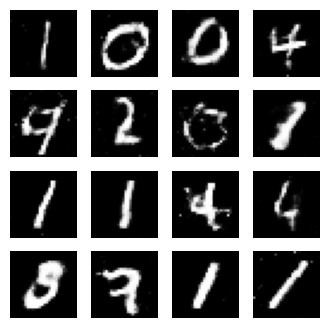

[Epoch 201/300] Loss_D: 0.5181, Loss_G: 1.3657, Time: 3867.43s
[Epoch 202/300] Loss_D: 0.5147, Loss_G: 1.3602, Time: 3886.34s
[Epoch 203/300] Loss_D: 0.5174, Loss_G: 1.3616, Time: 3913.51s
[Epoch 204/300] Loss_D: 0.5172, Loss_G: 1.3499, Time: 3940.55s
[Epoch 205/300] Loss_D: 0.5198, Loss_G: 1.3631, Time: 3967.16s
[Epoch 206/300] Loss_D: 0.5161, Loss_G: 1.3534, Time: 3993.99s
[Epoch 207/300] Loss_D: 0.5174, Loss_G: 1.3914, Time: 4020.41s
[Epoch 208/300] Loss_D: 0.5170, Loss_G: 1.3677, Time: 4047.38s
[Epoch 209/300] Loss_D: 0.5155, Loss_G: 1.3757, Time: 4074.07s
[Epoch 210/300] Loss_D: 0.5161, Loss_G: 1.3603, Time: 4100.45s
[Epoch 211/300] Loss_D: 0.5136, Loss_G: 1.3609, Time: 4126.41s
[Epoch 212/300] Loss_D: 0.5150, Loss_G: 1.3933, Time: 4152.86s
[Epoch 213/300] Loss_D: 0.5111, Loss_G: 1.3709, Time: 4179.59s
[Epoch 214/300] Loss_D: 0.5159, Loss_G: 1.3678, Time: 4206.22s
[Epoch 215/300] Loss_D: 0.5166, Loss_G: 1.3783, Time: 4232.38s
[Epoch 216/300] Loss_D: 0.5141, Loss_G: 1.3716, Time: 4

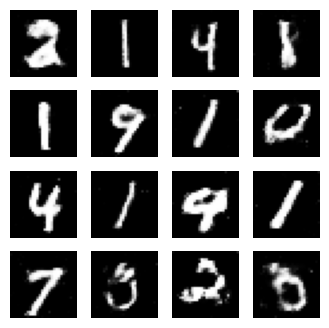

[Epoch 221/300] Loss_D: 0.5130, Loss_G: 1.3871, Time: 4391.44s
[Epoch 222/300] Loss_D: 0.5099, Loss_G: 1.3851, Time: 4417.42s
[Epoch 223/300] Loss_D: 0.5123, Loss_G: 1.3878, Time: 4443.89s
[Epoch 224/300] Loss_D: 0.5125, Loss_G: 1.3541, Time: 4470.74s
[Epoch 225/300] Loss_D: 0.5108, Loss_G: 1.3985, Time: 4497.05s
[Epoch 226/300] Loss_D: 0.5104, Loss_G: 1.3737, Time: 4523.85s
[Epoch 227/300] Loss_D: 0.5103, Loss_G: 1.3775, Time: 4550.44s
[Epoch 228/300] Loss_D: 0.5103, Loss_G: 1.3913, Time: 4576.99s
[Epoch 229/300] Loss_D: 0.5114, Loss_G: 1.3835, Time: 4603.69s
[Epoch 230/300] Loss_D: 0.5102, Loss_G: 1.3857, Time: 4630.20s
[Epoch 231/300] Loss_D: 0.5091, Loss_G: 1.3745, Time: 4656.36s
[Epoch 232/300] Loss_D: 0.5092, Loss_G: 1.4008, Time: 4682.55s
[Epoch 233/300] Loss_D: 0.5094, Loss_G: 1.3780, Time: 4709.17s
[Epoch 234/300] Loss_D: 0.5081, Loss_G: 1.4075, Time: 4735.44s
[Epoch 235/300] Loss_D: 0.5077, Loss_G: 1.4016, Time: 4762.16s
[Epoch 236/300] Loss_D: 0.5095, Loss_G: 1.3916, Time: 4

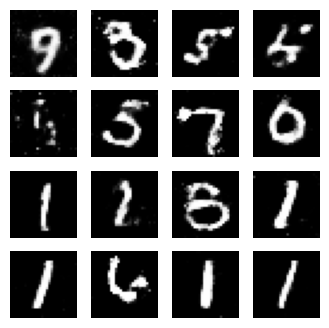

[Epoch 241/300] Loss_D: 0.5083, Loss_G: 1.3937, Time: 4921.21s
[Epoch 242/300] Loss_D: 0.5088, Loss_G: 1.4024, Time: 4947.66s
[Epoch 243/300] Loss_D: 0.5080, Loss_G: 1.3890, Time: 4974.22s
[Epoch 244/300] Loss_D: 0.5093, Loss_G: 1.4055, Time: 5000.72s
[Epoch 245/300] Loss_D: 0.5060, Loss_G: 1.3647, Time: 5027.19s
[Epoch 246/300] Loss_D: 0.5066, Loss_G: 1.4097, Time: 5053.68s
[Epoch 247/300] Loss_D: 0.5074, Loss_G: 1.3962, Time: 5080.00s
[Epoch 248/300] Loss_D: 0.5071, Loss_G: 1.4114, Time: 5107.12s
[Epoch 249/300] Loss_D: 0.5042, Loss_G: 1.3994, Time: 5133.60s
[Epoch 250/300] Loss_D: 0.5067, Loss_G: 1.3941, Time: 5160.06s
[Epoch 251/300] Loss_D: 0.5052, Loss_G: 1.3994, Time: 5186.48s
[Epoch 252/300] Loss_D: 0.5049, Loss_G: 1.4149, Time: 5213.22s
[Epoch 253/300] Loss_D: 0.5058, Loss_G: 1.4071, Time: 5240.13s
[Epoch 254/300] Loss_D: 0.5058, Loss_G: 1.4203, Time: 5266.52s
[Epoch 255/300] Loss_D: 0.5049, Loss_G: 1.3942, Time: 5292.94s
[Epoch 256/300] Loss_D: 0.5051, Loss_G: 1.4138, Time: 5

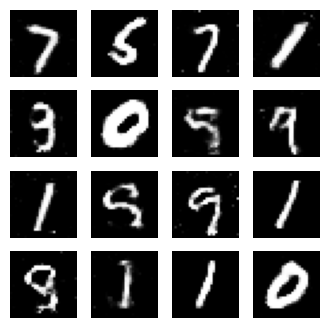

[Epoch 261/300] Loss_D: 0.5049, Loss_G: 1.4293, Time: 5451.67s
[Epoch 262/300] Loss_D: 0.5031, Loss_G: 1.4041, Time: 5478.46s
[Epoch 263/300] Loss_D: 0.5040, Loss_G: 1.4066, Time: 5505.04s
[Epoch 264/300] Loss_D: 0.5049, Loss_G: 1.4056, Time: 5531.01s
[Epoch 265/300] Loss_D: 0.5021, Loss_G: 1.3843, Time: 5557.39s
[Epoch 266/300] Loss_D: 0.5047, Loss_G: 1.4248, Time: 5585.11s
[Epoch 267/300] Loss_D: 0.5025, Loss_G: 1.4280, Time: 5611.59s
[Epoch 268/300] Loss_D: 0.5013, Loss_G: 1.4122, Time: 5638.83s
[Epoch 269/300] Loss_D: 0.5015, Loss_G: 1.4207, Time: 5659.55s
[Epoch 270/300] Loss_D: 0.5037, Loss_G: 1.4248, Time: 5681.02s
[Epoch 271/300] Loss_D: 0.5027, Loss_G: 1.4038, Time: 5708.37s
[Epoch 272/300] Loss_D: 0.5041, Loss_G: 1.3967, Time: 5735.46s
[Epoch 273/300] Loss_D: 0.5027, Loss_G: 1.4250, Time: 5761.99s
[Epoch 274/300] Loss_D: 0.5035, Loss_G: 1.4123, Time: 5788.69s
[Epoch 275/300] Loss_D: 0.4996, Loss_G: 1.4263, Time: 5814.90s
[Epoch 276/300] Loss_D: 0.5002, Loss_G: 1.4169, Time: 5

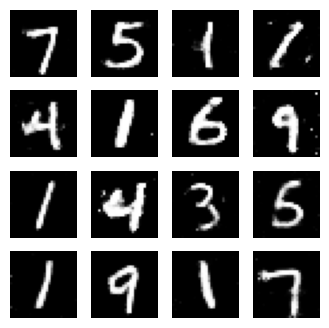

[Epoch 281/300] Loss_D: 0.5011, Loss_G: 1.4057, Time: 5943.79s
[Epoch 282/300] Loss_D: 0.5018, Loss_G: 1.4239, Time: 5956.39s
[Epoch 283/300] Loss_D: 0.4989, Loss_G: 1.4305, Time: 5968.97s
[Epoch 284/300] Loss_D: 0.4990, Loss_G: 1.4202, Time: 5981.83s
[Epoch 285/300] Loss_D: 0.5014, Loss_G: 1.4139, Time: 5994.95s
[Epoch 286/300] Loss_D: 0.4989, Loss_G: 1.4198, Time: 6007.50s
[Epoch 287/300] Loss_D: 0.5031, Loss_G: 1.4282, Time: 6020.10s
[Epoch 288/300] Loss_D: 0.4987, Loss_G: 1.4142, Time: 6032.65s
[Epoch 289/300] Loss_D: 0.4994, Loss_G: 1.4298, Time: 6045.92s
[Epoch 290/300] Loss_D: 0.4994, Loss_G: 1.4234, Time: 6058.76s
[Epoch 291/300] Loss_D: 0.5000, Loss_G: 1.4180, Time: 6072.25s
[Epoch 292/300] Loss_D: 0.4993, Loss_G: 1.4527, Time: 6084.58s
[Epoch 293/300] Loss_D: 0.4972, Loss_G: 1.4292, Time: 6097.21s
[Epoch 294/300] Loss_D: 0.4972, Loss_G: 1.4306, Time: 6109.70s
[Epoch 295/300] Loss_D: 0.4995, Loss_G: 1.4364, Time: 6122.52s
[Epoch 296/300] Loss_D: 0.4957, Loss_G: 1.4416, Time: 6

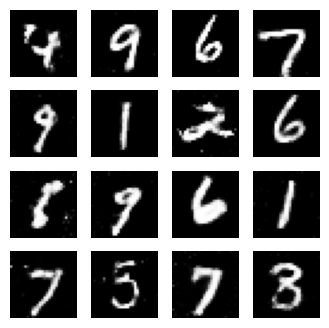

In [9]:
t0 = time.perf_counter()  # High-resolution timer
for epoch in range(1, epochs + 1):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0

    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device, non_blocking=True)
        b = real_imgs.size(0)
        valid = torch.ones(b, 1, device=device)
        fake = torch.zeros(b, 1, device=device)

        # -- Discriminator
        optimizer_D.zero_grad()
        loss_real = criterion(discriminator(real_imgs), valid)
        z = torch.randn(b, latent_dim, device=device)
        gen_imgs = generator(z)
        loss_fake = criterion(discriminator(gen_imgs.detach()), fake)
        loss_D = (loss_real + loss_fake) * 0.5
        loss_D.backward()
        optimizer_D.step()

        # -- Generator
        optimizer_G.zero_grad()
        loss_G = criterion(discriminator(gen_imgs), valid)
        loss_G.backward()
        optimizer_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

    avg_loss_D = epoch_loss_D / len(train_loader)
    avg_loss_G = epoch_loss_G / len(train_loader)
    elapsed = time.perf_counter() - t0

    history['epoch'] += 1
    history['loss_D'].append(avg_loss_D)
    history['loss_G'].append(avg_loss_G)
    history['epoch_time_sec'].append(elapsed)

    print(f"[Epoch {epoch}/{epochs}] Loss_D: {avg_loss_D:.4f}, Loss_G: {avg_loss_G:.4f}, Time: {elapsed:.2f}s")

    if epoch % 20 == 0 or epoch == 1:
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim, device=device)
            test_imgs = generator(test_z).cpu()
            fig, axes = plt.subplots(4, 4, figsize=(4, 4))
            for img, ax in zip(test_imgs, axes.flatten()):
                ax.imshow(img.squeeze() * 0.5 + 0.5, cmap='gray')
                ax.axis('off')
            plt.show()

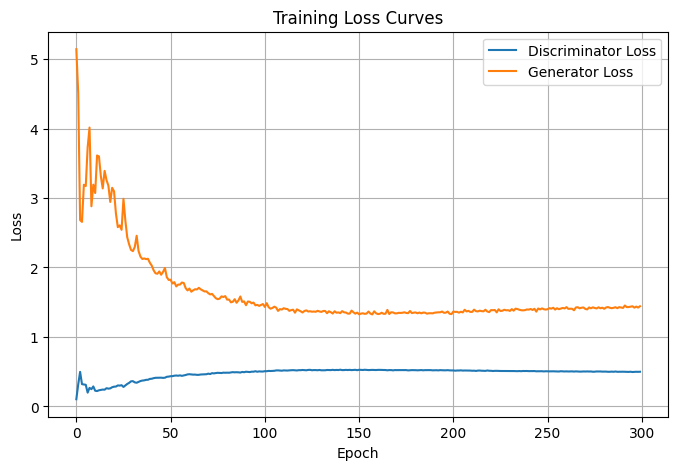

In [10]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['loss_D'], label='Discriminator Loss')
plt.plot(range(300), history['loss_G'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curves')
plt.grid(True)
plt.show()

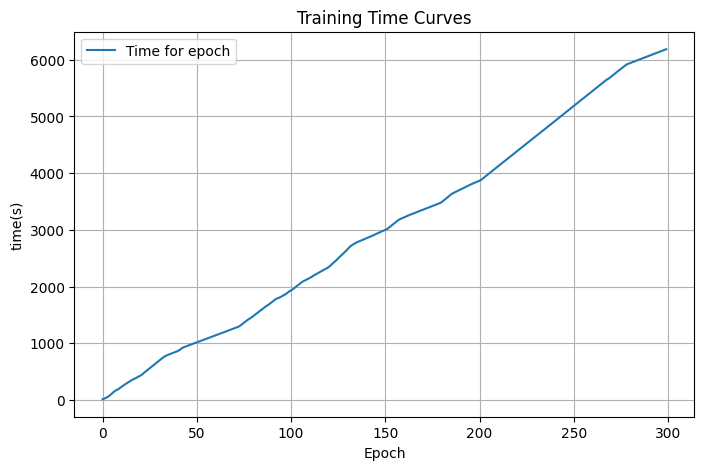

In [11]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['epoch_time_sec'], label='Time for epoch')
plt.xlabel('Epoch')
plt.ylabel('time(s)')
plt.legend()
plt.title('Training Time Curves')
plt.grid(True)
plt.show()

In [12]:
# Export to CSV
csv_file = 'GAN_training_history.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['epoch', 'loss_D', 'loss_G', 'epoch_time_sec'])
    writer.writeheader()
    for e, ld, lg, t in zip(range(history['epoch']), history['loss_D'], history['loss_G'], history['epoch_time_sec']):
        writer.writerow({'epoch': e, 'loss_D': ld, 'loss_G': lg, 'epoch_time_sec': t})

print(f"Training history exported to {csv_file}")

Training history exported to GAN_training_history.csv


In [13]:
# import os
# def read_history_from_file(path, history):
#     """
#     Read training history from a CSV or JSON file and merge into `history` dict.
#     - `path`: path to CSV or JSON file (supports .csv and .json).
#     - `history`: dict expected to contain at least 'epoch' and some list fields, e.g.
#         {'epoch': 0, 'loss_D': [], 'loss_G': [], 'epoch_time_sec': []}
#     Returns updated history (same object).
#     """
#     if not os.path.isfile(path):
#         raise FileNotFoundError(f"No file at: {path}")

#     ext = os.path.splitext(path)[1].lower()
#     rows = []

#     if ext == '.csv':
#         with open(path, 'r', newline='') as f:
#             reader = csv.DictReader(f)
#             for r in reader:
#                 rows.append(r)
#     elif ext == '.json':
#         with open(path, 'r') as f:
#             data = json.load(f)
#             # Accept either list-of-rows or dict-of-lists
#             if isinstance(data, list):
#                 rows = data
#             elif isinstance(data, dict):
#                 # convert dict-of-lists to list-of-rows
#                 keys = list(data.keys())
#                 # find length
#                 length = len(data[keys[0]]) if keys else 0
#                 for i in range(length):
#                     row = {k: data[k][i] for k in keys}
#                     rows.append(row)
#             else:
#                 raise ValueError("JSON format not recognized: must be list or dict-of-lists")
#     else:
#         raise ValueError("Unsupported file extension. Use .csv or .json")

#     # Parse rows into canonical numeric values
#     parsed = []
#     for r in rows:
#         parsed_row = {}
#         for k, v in r.items():
#             if v is None or v == '':
#                 parsed_row[k] = None
#                 continue
#             # try int then float else keep string
#             try:
#                 iv = int(v)
#                 parsed_row[k] = iv
#             except Exception:
#                 try:
#                     fv = float(v)
#                     parsed_row[k] = fv
#                 except Exception:
#                     parsed_row[k] = v
#         parsed.append(parsed_row)

#     # Which epochs already in history?
#     existing_epochs = set()
#     if 'epoch' in history and isinstance(history['epoch'], int):
#         # history['epoch'] stores last epoch count, but we need epoch numbers present in lists
#         # Try to reconstruct existing epoch list length from one of the loss lists (if present).
#         # We'll treat history lists as aligned in order.
#         existing_len = None
#         for key, val in history.items():
#             if key == 'epoch': 
#                 continue
#             if isinstance(val, list):
#                 if existing_len is None or len(val) > existing_len:
#                     existing_len = len(val)
#         if existing_len is not None:
#             # assume stored epochs are 1..existing_len
#             existing_epochs = set(range(1, existing_len + 1))
#         else:
#             existing_epochs = set()

#     # Merge: determine numeric epoch column name (may be 'epoch' or 'Epoch')
#     epoch_key = None
#     if parsed:
#         possible_epoch_names = ['epoch', 'Epoch', 'iter', 'iteration', 'step']
#         for name in possible_epoch_names:
#             if name in parsed[0]:
#                 epoch_key = name
#                 break
#         # fallback to first numeric column if no 'epoch' found
#         if epoch_key is None:
#             # choose the first key whose values are ints across rows
#             for k in parsed[0].keys():
#                 if all(isinstance(row.get(k, None), int) for row in parsed):
#                     epoch_key = k
#                     break

#     if epoch_key is None:
#         raise ValueError("Couldn't find an epoch/step column in the file. Expected column named 'epoch' or similar.")

#     # Ensure history has list containers for all columns found (except epoch)
#     for k in parsed[0].keys():
#         if k == epoch_key:
#             continue
#         if k not in history:
#             history[k] = []

#     # Append only new epochs (avoid duplicates)
#     appended = 0
#     for row in parsed:
#         ep = row.get(epoch_key)
#         if ep is None:
#             continue
#         if ep in existing_epochs:
#             continue
#         # append values for each key in history (skip epoch key)
#         for k in history.keys():
#             if k == 'epoch':
#                 continue
#             history[k].append(row.get(k))
#         appended += 1
#         existing_epochs.add(ep)

#     # Update history['epoch'] to max epoch (if numeric rows exist)
#     epochs_in_file = [r.get(epoch_key) for r in parsed if isinstance(r.get(epoch_key), (int, float))]
#     if epochs_in_file:
#         # take max int
#         max_epoch = int(max(epochs_in_file))
#         if 'epoch' in history and isinstance(history['epoch'], int):
#             history['epoch'] = max(history['epoch'], max_epoch)
#         else:
#             history['epoch'] = max_epoch

#     print(f"Read {len(parsed)} rows from '{path}', appended {appended} new entries to history.")
#     return history

In [14]:
# history = read_history_from_file("GAN_training_history.csv", history)